# import

In [42]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim


# 多値分類

## データ読み込み

In [17]:
iris = load_iris() # データ読み込み

x_org, y_org = iris.data, iris.target

print(x_org.shape)
print(y_org.shape)


(150, 4)
(150,)


## データ絞り込み
クラスは3つ・特徴量は2つ

In [21]:
x_select = x_org[:, [0, 2]] # 2つの特徴量を選択

print(x_select.shape, y_org.shape)


(150, 2) (150,)


## 訓練データと検証データの分離

In [23]:
x_train, x_valid, y_train, y_valid = train_test_split(x_select, y_org, train_size=0.5, test_size=0.5, random_state=123)
print(x_train.shape, x_valid.shape, y_train.shape, y_valid.shape)


(75, 2) (75, 2) (75,) (75,)


## 訓練データの散布図
2つの特徴量があれば分類できそうだよ．

In [25]:
print(type(x_train))

<class 'numpy.ndarray'>


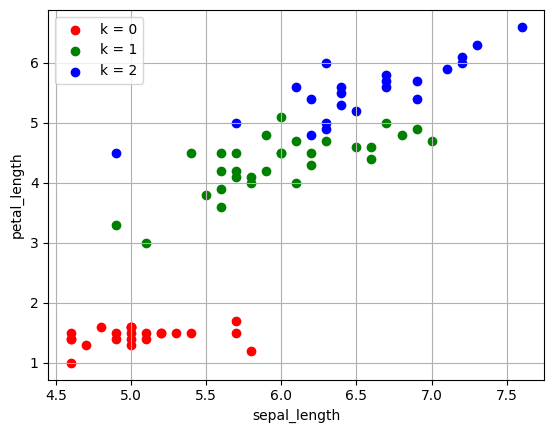

In [30]:
for k, color in enumerate(['r', 'g', 'b']):
    plt.scatter(x_train[y_train == k, 0], x_train[y_train == k, 1], c=color, label=f'k = {k}')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.legend()
plt.grid()
plt.show()


## モデル定義

In [ ]:
n_input = x_train.shape[1] # 入力次元
n_output = len(np.unique(y_train)) # 出力次元

print(n_input, n_output)


2 3


In [36]:
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()

        self.l1 = nn.Linear(n_input, n_output)
    
    def forward(self, x):
        x1 = self.l1(x)
        return x1

net = Net(n_input=n_input, n_output=n_output)


## モデル内のパラメータ確認

In [38]:
for parameter in net.named_parameters():
    print(parameter)


('l1.weight', Parameter containing:
tensor([[-0.6295, -0.0742],
        [ 0.1580,  0.1059],
        [-0.4229,  0.3143]], requires_grad=True))
('l1.bias', Parameter containing:
tensor([ 0.4725,  0.1603, -0.5030], requires_grad=True))


## データのテンソル化

In [51]:
inputs_train = torch.tensor(x_train, dtype=torch.float32)
labels_train = torch.tensor(y_train, dtype=torch.long)

inputs_valid = torch.tensor(x_valid, dtype=torch.float32)
labels_valid = torch.tensor(y_valid, dtype=torch.long)

print(inputs_train.shape, labels_train.shape)
print(inputs_valid.shape, labels_valid.shape)


torch.Size([75, 2]) torch.Size([75])
torch.Size([75, 2]) torch.Size([75])


## 学習ループ

In [52]:
epochs = 10000

criterion = nn.CrossEntropyLoss() # 損失関数

lr = 0.01 # 学習率
optimizer = optim.SGD(net.parameters(), lr=lr) # 最適化関数

history = np.zeros((0, 5))


In [55]:
for epoch in range(epochs):
    # 訓練
    optimizer.zero_grad() # 勾配の初期化
    outputs = net(inputs_train) # 予測
    loss = criterion(outputs, labels_train) # 損失
    loss.backward() # 勾配計算
    optimizer.step() # パラメータ更新

    # 訓練の記録
    loss_train = loss # 損失
    values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
    acc_train = (indices == labels_train).float().mean() # 正解率

    with torch.no_grad():
        # 検証
        outputs = net(inputs_valid) # 予測
        loss = criterion(outputs, labels_valid) # 損失

        # 検証の記録
        loss_valid = loss # 損失
        values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
        acc_valid = (indices == labels_valid).float().mean() # 正解率
    
    # 学習履歴の記録
    if (epoch % 10) == 0:
        item = np.array([epoch, loss_train.item(), acc_train.item(), loss_valid.item(), acc_valid.item()])
        history = np.vstack((history, item))
        print(f"epoch: {epoch}, loss_train: {loss_train}, acc_train: {acc_train}, loss_valid: {loss_valid}, acc_valid: {acc_valid}")


epoch: 0, loss_train: 1.8118304014205933, acc_train: 0.4000000059604645, loss_valid: 1.9459136724472046, acc_valid: 0.2666666805744171
epoch: 10, loss_train: 1.0681334733963013, acc_train: 0.6133333444595337, loss_valid: 1.107033610343933, acc_valid: 0.5733333230018616
epoch: 20, loss_train: 0.9528084397315979, acc_train: 0.6266666650772095, loss_valid: 0.963180422782898, acc_valid: 0.6000000238418579
epoch: 30, loss_train: 0.9144351482391357, acc_train: 0.6399999856948853, loss_valid: 0.9163554906845093, acc_valid: 0.6000000238418579
epoch: 40, loss_train: 0.8894401788711548, acc_train: 0.6266666650772095, loss_valid: 0.8880841135978699, acc_valid: 0.6133333444595337
epoch: 50, loss_train: 0.8671122193336487, acc_train: 0.6399999856948853, loss_valid: 0.864137589931488, acc_valid: 0.6133333444595337
epoch: 60, loss_train: 0.8463812470436096, acc_train: 0.6266666650772095, loss_valid: 0.8422958850860596, acc_valid: 0.6266666650772095
epoch: 70, loss_train: 0.8270684480667114, acc_train

### `outputs`のカタチ

In [57]:
with torch.no_grad():
    # 検証
    outputs = net(inputs_valid) # 予測
    print(outputs.shape)
    print(outputs)
    loss = criterion(outputs, labels_valid) # 損失

    # 検証の記録
    loss_valid = loss # 損失
    values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
    acc_valid = (indices == labels_valid).float().mean() # 正解率

torch.Size([75, 3])
tensor([[ -5.2039,   0.9063,   0.4879],
        [ -6.4391,   0.9149,   1.4748],
        [ -7.4448,   0.8834,   2.9044],
        [ -3.6122,   0.8925,  -0.7406],
        [  4.5109,   0.9595,  -9.2387],
        [ -5.3566,   0.8901,   0.8906],
        [ -3.4851,   0.9275,  -1.4251],
        [  4.0272,   0.9296,  -8.3126],
        [  3.6835,   0.9253,  -7.9300],
        [ -4.8090,   0.8729,   0.6689],
        [ -4.8985,   0.9387,  -0.3173],
        [  5.5038,   1.0004, -10.8092],
        [ -3.5867,   0.8737,  -0.4589],
        [ -6.9355,   0.8944,   2.2601],
        [ -7.0123,   0.9508,   1.4147],
        [ -7.9668,   0.8817,   3.4079],
        [  5.8476,   1.0047, -11.1918],
        [  4.5493,   0.9313,  -8.8160],
        [ -4.8474,   0.9011,   0.2462],
        [  4.3454,   0.9526,  -8.9769],
        [  5.0074,   0.9799, -10.0239],
        [ -5.8914,   0.8978,   1.2532],
        [  2.6266,   0.9314,  -7.0639],
        [ -5.5349,   0.8926,   1.0114],
        [  4.1544,  